 Team Members: Brandon, Christina and Isaac

Note: you may need to restart the kernel to use updated packages.
Imports loaded
Local model: llama3.2:latest
Available tools:
 - price_data
 - company_info
 - financials
 - cash_flow
Agent created successfully


Enter stock ticker (e.g., AAPL, MSFT, NVDA):  NVDA



🔎 Checking ticker: NVDA
✅ Found NVDA. Starting investment research...

AGENTIC MARKET RESEARCH: NVDA

🧠 STEP 1 — PLANS
    Plans research steps for the stock symbol.
{
  "objectives": [
    "Investigate the factors contributing to NVIDIA's high valuation metrics",
    "Examine the accuracy of NVIDIA's cash flow pattern",
    "Analyze the company's capital expenditure and its impact on the business"
  ],
  "tools": [
    "financials",
    "cash_flow"
  ],
  "questions": [
    "What are the factors contributing to NVIDIA's high valuation metrics?",
    "What is the accuracy of NVIDIA's cash flow pattern?",
    "What is the explanation for NVIDIA's negative capital expenditure for 2026?"
  ]
}

🧠 STEP 2 — Uses tools
    Selects and executes research tools dynamically.
🔧 Running tool: financials
🔧 Running tool: cash_flow

📊 RAW OBSERVATIONS
{
  "financials": {
    "Total Revenue": {
      "2026-01-31 00:00:00": 215938000000.0,
      "2025-01-31 00:00:00": 130497000000.0,
      "2024-01-31

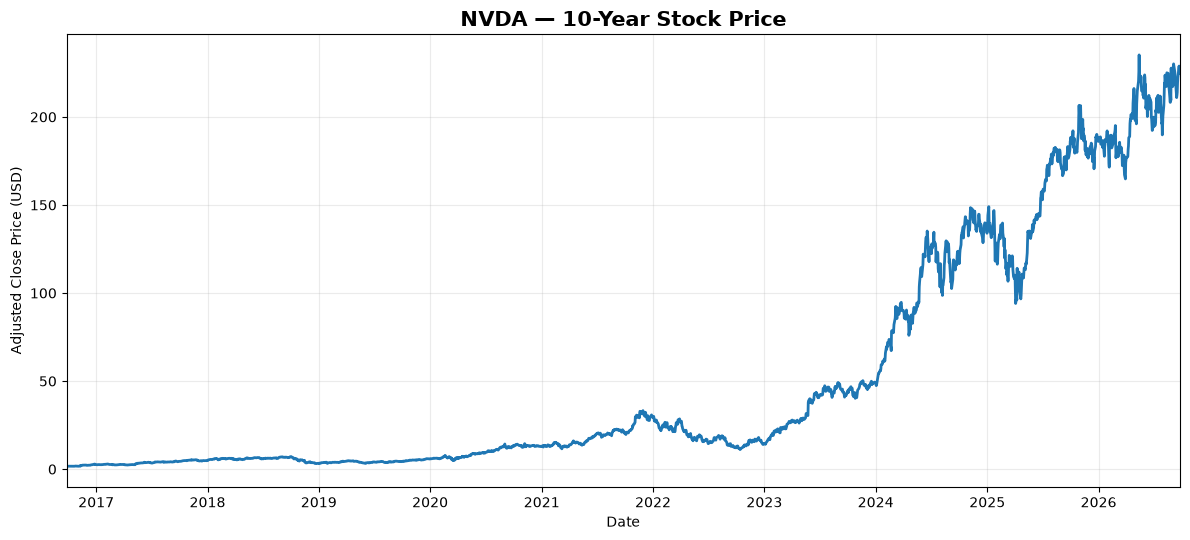

10-year price summary: $1.58 → $225.07 (+14,159.0%)

══════════════════════════════════════════════════════════════════════════════
  END OF REPORT
══════════════════════════════════════════════════════════════════════════════

LLM RESEARCH REPORT
# NVDA Market Research

## 1. Company Overview

NVIDIA Corporation (NVDA) is a leading global provider of graphics processing units (GPUs) and high-performance computing (HPC) solutions. Founded in 1993, the company is headquartered in Santa Clara, California, and is a major player in the technology industry.

## 2. Price Performance

Unfortunately, the latest stock price is unavailable. As such, we cannot provide information on the company's current price performance.

## 3. Valuation

NVIDIA's high valuation metrics can be attributed to several factors. The company's dominance in the GPU market, strong revenue growth, and increasing demand for its products contribute to its high valuation.

## 4. Financial Performance

The company's financi

In [1]:
#
print("\033[1m Team Members: Brandon, Christina and Isaac\033[0m")
print()
#

%pip install -q "pandas<3" ollama yfinance matplotlib

# ======================================================================
# AAI-520 Team 8 Team Project — (Brandon, Christina and Isaac) Task Status
# ======================================================================
#
# ======================================================================
# Isaac — Market & Planning
# ======================================================================
#
# 1. Implement Router
#
# 2. Implement Planner Agent
#
# 3. Build Yahoo Finance market data tools
#
# 4. Calculate market metrics
#
# 5. Implement Market Agent
#
# 6. Additional Person 1 task(s) hidden in screenshot
#
# ======================================================================
# Brandon — Financial & Evaluation
# ======================================================================
#
# 1. Build financial statements tool
#
# 2. Implement Evaluator Agent
#
# 3. Implement Self-Reflection
#
# 4. Implement Optimizer
#
# 5. Define evaluation criteria / rubric
#
# 6. Implement Financial Agent
#
# ======================================================================
# Brandon, Christina and Isaac
# ======================================================================
#
# 1. End-to-end demo + learning-across-runs demo
#
# 2. Configure dependencies & environment
#
# 3. Full system testing
#    (component, routing, evaluator, memory)
#
# 4. Define shared LangGraph state schema
#
# 5. Finalize project scope & MVP definition
#
# 6. Additional Whole Group task(s) hidden in screenshot
#
# ======================================================================
# Christina — News & Memory
# ======================================================================
#
# 1. Integrate memory with planning
#
# 2. Implement Synthesis Agent
#
# 3. Implement persistent memory
#
# 4. Build news retrieval tool
#
# 5. Build prompt chaining news workflow
#    (ingest to summarize)
#
# 6. Additional Person 3 task(s) hidden in screenshot
#
# ======================================================================
# End of Task Status
# ======================================================================

import json
from pathlib import Path
from datetime import datetime

import ollama
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

MODEL = "llama3.2:latest"
MEMORY_FILE = Path("market_agent_memory.json")

print("Imports loaded")
print(f"Local model: {MODEL}")

def ask_llm(prompt):
    response = ollama.chat(
        model=MODEL,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )
    
    return response["message"]["content"]

#test = ask_llm(
#    "You are a financial research assistant. "
#    "Give me a 3-step research plan for AAPL."
#)

#print(test)

def get_price_data(symbol, period="1y"):
    ticker = yf.Ticker(symbol)
    df = ticker.history(period=period)

    if df.empty:
        return {"error": f"No price data found for {symbol}"}

    close = df["Close"]

    start_price = float(close.iloc[0])
    latest_price = float(close.iloc[-1])

    total_return = (
        latest_price / start_price - 1
    ) * 100

    daily_returns = close.pct_change().dropna()

    volatility = (
        daily_returns.std() * (252 ** 0.5)
    ) * 100

    running_max = close.cummax()

    drawdown = (
        close / running_max - 1
    ) * 100

    return {
        "start_price": round(start_price, 2),
        "latest_price": round(latest_price, 2),
        "1y_return_percent": round(total_return, 2),
        "annualized_volatility_percent": round(
            float(volatility), 2
        ),
        "maximum_drawdown_percent": round(
            float(drawdown.min()), 2
        ),
        "observations": len(df),
    }

def get_company_info(symbol):
    ticker = yf.Ticker(symbol)

    info = ticker.info

    fields = [
        "longName",
        "sector",
        "industry",
        "country",
        "marketCap",
        "enterpriseValue",
        "currentPrice",
        "trailingPE",
        "forwardPE",
        "priceToSalesTrailing12Months",
        "profitMargins",
        "operatingMargins",
        "returnOnEquity",
        "beta",
        "dividendYield",
    ]

    return {
        field: info.get(field)
        for field in fields
    }

def get_financials(symbol):
    ticker = yf.Ticker(symbol)

    income = ticker.income_stmt

    if income.empty:
        return {"error": "No financial statements found"}

    wanted = [
        "Total Revenue",
        "Operating Income",
        "Net Income",
        "EBITDA",
        "Diluted EPS",
    ]

    available = [
        row for row in wanted
        if row in income.index
    ]

    result = {}

    for row in available:
        values = income.loc[row].iloc[:4]

        result[row] = {
            str(date): (
                None if pd.isna(value)
                else float(value)
            )
            for date, value in values.items()
        }

    return result

def get_cash_flow(symbol):
    ticker = yf.Ticker(symbol)

    cashflow = ticker.cashflow

    if cashflow.empty:
        return {"error": "No cash-flow data found"}

    wanted = [
        "Operating Cash Flow",
        "Free Cash Flow",
        "Capital Expenditure",
    ]

    available = [
        row for row in wanted
        if row in cashflow.index
    ]

    result = {}

    for row in available:
        values = cashflow.loc[row].iloc[:4]

        result[row] = {
            str(date): (
                None if pd.isna(value)
                else float(value)
            )
            for date, value in values.items()
        }

    return result

TOOLS = {
    "price_data": get_price_data,
    "company_info": get_company_info,
    "financials": get_financials,
    "cash_flow": get_cash_flow,
}

print("Available tools:")

for name in TOOLS:
    print(" -", name)

def load_memory():
    if not MEMORY_FILE.exists():
        return []

    try:
        with open(MEMORY_FILE, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return []


def save_memory(symbol, summary, weaknesses):
    memories = load_memory()

    memories.append({
        "date": datetime.now().isoformat(),
        "symbol": symbol,
        "summary": summary,
        "weaknesses": weaknesses,
    })

    # Keep the most recent 20 memories
    memories = memories[-20:]

    with open(MEMORY_FILE, "w", encoding="utf-8") as f:
        json.dump(memories, f, indent=2)


def get_memory(symbol):
    memories = load_memory()

    return [
        m for m in memories
        if m.get("symbol") == symbol
    ]

import json
import re
from numbers import Number

import yfinance as yf



def plot_10_year_stock_price(symbol):
    """Display a clean 10-year adjusted stock-price chart."""
    try:
        history = yf.Ticker(symbol).history(period="10y", auto_adjust=True)

        if history.empty:
            print("\n10-YEAR STOCK PRICE")
            print("No 10-year price history was available.")
            return

        close = history["Close"].dropna()

        fig, ax = plt.subplots(figsize=(12, 5.5))
        ax.plot(close.index, close.values, linewidth=2)
        ax.set_title(f"{symbol} — 10-Year Stock Price", fontsize=15, fontweight="bold")
        ax.set_xlabel("Date")
        ax.set_ylabel("Adjusted Close Price (USD)")
        ax.grid(True, alpha=0.25)
        ax.margins(x=0)
        fig.tight_layout()
        plt.show()

        start_price = float(close.iloc[0])
        end_price = float(close.iloc[-1])
        total_return = ((end_price / start_price) - 1) * 100

        print(
            f"10-year price summary: "
            f"${start_price:,.2f} → ${end_price:,.2f} "
            f"({total_return:+,.1f}%)"
        )

    except Exception as exc:
        print(f"Could not display 10-year stock chart: {type(exc).__name__}: {exc}")


class MarketResearchAgent:
    def __init__(self):
        self.model = MODEL

    # =========================================================
    # AGENTIC CAPABILITY 1 — PLANNING
    # =========================================================

    def ask(self, prompt):
        return ask_llm(prompt)

    # =========================================================
    # JSON PARSER
    # =========================================================

    def parse_json_response(self, response, fallback=None):
        """
        Safely parse JSON returned by an LLM.

        Handles:
        - normal JSON
        - Markdown code fences
        - explanatory text before/after JSON
        """

        if not response or not isinstance(response, str):
            return fallback

        text = response.strip()

        # Attempt 1: direct JSON
        try:
            return json.loads(text)
        except json.JSONDecodeError:
            pass

        # Remove Markdown code fences
        text = re.sub(
            r"^```(?:json)?\s*",
            "",
            text,
            flags=re.IGNORECASE,
        )

        text = re.sub(
            r"\s*```$",
            "",
            text,
        ).strip()

        # Attempt 2: JSON after removing fences
        try:
            return json.loads(text)
        except json.JSONDecodeError:
            pass

        # Attempt 3: extract JSON object
        start = text.find("{")
        end = text.rfind("}")

        if start != -1 and end > start:
            candidate = text[start:end + 1]

            try:
                return json.loads(candidate)
            except json.JSONDecodeError:
                pass

        return fallback

    # =========================================================
    # AGENTIC CAPABILITY 1 — PLANNING
    # =========================================================

    def plan(self, symbol):
        """
        Plans the research steps for a given stock symbol.

        Uses previous memory to make future research more
        context-aware and avoid repeating unresolved work.
        """

        # -----------------------------------------------------
        # LEARNING ACROSS RUNS
        # Retrieve previous research memory
        # -----------------------------------------------------

        previous_memory = get_memory(symbol)

        if previous_memory is None:
            previous_memory = []

        if not isinstance(previous_memory, list):
            previous_memory = [previous_memory]

        # Only provide the most recent memory to the planner
        recent_memory = previous_memory[-3:]

        # -----------------------------------------------------
        # Available dynamic tools
        # -----------------------------------------------------

        available_tools = list(TOOLS.keys())

        prompt = f"""
You are the planning component of a financial research agent.

Stock symbol:
{symbol}

Previous research memory:
{json.dumps(recent_memory, indent=2, default=str)}

Available tools:
{json.dumps(available_tools, indent=2)}

Create a research plan.

Rules:

1. Only select tools from the available tool list.
2. Do not invent tools.
3. Prefer tools that directly answer the research objectives.
4. Use previous memory to avoid repeating unresolved work.
5. Identify questions that were not adequately answered in previous runs.
6. Do not make investment recommendations.
7. Do not assume data exists before the tools are executed.
8. Keep the research focused on the supplied stock symbol.

Return ONLY a valid JSON object.

Required schema:

{{
    "objectives": [],
    "tools": [],
    "questions": []
}}
"""

        response = self.ask(prompt)

        fallback = {
            "objectives": [
                "Analyze price performance",
                "Analyze company information",
                "Analyze valuation",
                "Analyze financial performance",
                "Analyze cash generation",
            ],
            "tools": [
                tool
                for tool in [
                    "price_data",
                    "company_info",
                    "financials",
                    "cash_flow",
                ]
                if tool in TOOLS
            ],
            "questions": [
                "How has the stock performed?",
                "What is the company's business and operating profile?",
                "What valuation metrics are available?",
                "How are revenue and earnings performing?",
                "What does the available cash-flow data show?",
            ],
        }

        plan = self.parse_json_response(
            response,
            fallback,
        )

        if not isinstance(plan, dict):
            plan = fallback

        objectives = plan.get(
            "objectives",
            [],
        )

        tools = plan.get(
            "tools",
            [],
        )

        questions = plan.get(
            "questions",
            [],
        )

        if not isinstance(objectives, list):
            objectives = []

        if not isinstance(tools, list):
            tools = []

        if not isinstance(questions, list):
            questions = []

        # Only allow actual tools
        tools = [
            tool
            for tool in tools
            if isinstance(tool, str)
            and tool in TOOLS
        ]

        if not tools:
            tools = fallback["tools"]

        return {
            "objectives": objectives,
            "tools": tools,
            "questions": questions,
        }

    # =========================================================
    # AGENTIC CAPABILITY 2 — DYNAMIC TOOL USE
    # =========================================================

    def execute_tools(self, symbol, plan):
        """
        Dynamically executes the tools selected by the planner.
        """

        observations = {}

        for tool_name in plan.get("tools", []):

            print(
                f"🔧 Running tool: {tool_name}"
            )

            if tool_name not in TOOLS:

                observations[tool_name] = {
                    "error": "Tool is not available."
                }

                continue

            try:

                tool = TOOLS[tool_name]

                result = tool(symbol)

                if result is None:

                    result = {
                        "error": "Tool returned no data."
                    }

                observations[tool_name] = result

            except Exception as exc:

                observations[tool_name] = {
                    "error": (
                        f"{type(exc).__name__}: {exc}"
                    )
                }

        return observations

    # =========================================================
    # SUPPORTING STEP — DATA VALIDATION
    # =========================================================

    def validate_observations(
        self,
        symbol,
        observations,
    ):
        """
        Performs deterministic validation on collected data.
        """

        issues = []

        def find_value(
            obj,
            possible_keys,
        ):

            if isinstance(obj, dict):

                for key in possible_keys:

                    if key in obj:
                        return obj[key]

                for value in obj.values():

                    result = find_value(
                        value,
                        possible_keys,
                    )

                    if result is not None:
                        return result

            elif isinstance(obj, list):

                for item in obj:

                    result = find_value(
                        item,
                        possible_keys,
                    )

                    if result is not None:
                        return result

            return None

        # -----------------------------------------------------
        # Tool-level validation
        # -----------------------------------------------------

        for tool_name, data in observations.items():

            if data is None:

                issues.append({
                    "type": "missing",
                    "tool": tool_name,
                    "message": "Tool returned None.",
                })

                continue

            if (
                isinstance(data, dict)
                and "error" in data
            ):

                issues.append({
                    "type": "tool_error",
                    "tool": tool_name,
                    "message": str(data["error"]),
                })

        company = observations.get(
            "company_info",
            {},
        )

        financials = observations.get(
            "financials",
            {},
        )

        cash_flow = observations.get(
            "cash_flow",
            {},
        )

        price = observations.get(
            "price_data",
            {},
        )

        # -----------------------------------------------------
        # Locate important values
        # -----------------------------------------------------

        market_cap = find_value(
            company,
            [
                "market_cap",
                "marketCap",
                "marketCapitalization",
            ],
        )

        revenue = find_value(
            financials,
            [
                "total_revenue",
                "totalRevenue",
                "revenue",
                "Total Revenue",
            ],
        )

        operating_cash_flow = find_value(
            cash_flow,
            [
                "operating_cash_flow",
                "operatingCashFlow",
                "operating_cashflow",
                "Operating Cash Flow",
            ],
        )

        free_cash_flow = find_value(
            cash_flow,
            [
                "free_cash_flow",
                "freeCashFlow",
                "Free Cash Flow",
            ],
        )

        latest_price = find_value(
            price,
            [
                "latest_price",
                "current_price",
                "currentPrice",
                "regularMarketPrice",
                "price",
                "Current Price",
            ],
        )

        one_year_return = find_value(
            price,
            [
                "one_year_return",
                "one_year_return_pct",
                "1y_return",
                "return_1y",
            ],
        )

        # -----------------------------------------------------
        # Cash-flow consistency
        # -----------------------------------------------------

        if (
            operating_cash_flow is not None
            and free_cash_flow is None
        ):

            issues.append({
                "type": "missing",
                "field": "free_cash_flow",
                "message": (
                    "Operating cash flow exists, "
                    "but free cash flow is not available."
                ),
            })

        # -----------------------------------------------------
        # Price validation
        # -----------------------------------------------------

        if latest_price is None:

            issues.append({
                "type": "missing",
                "field": "latest_price",
                "message": (
                    "Latest stock price was not supplied."
                ),
            })

        # -----------------------------------------------------
        # Return validation
        # -----------------------------------------------------

        if one_year_return is None:

            issues.append({
                "type": "missing",
                "field": "one_year_return",
                "message": (
                    "One-year return was not supplied."
                ),
            })

        # -----------------------------------------------------
        # Market-cap sanity check
        # -----------------------------------------------------

        if (
            isinstance(market_cap, Number)
            and isinstance(revenue, Number)
            and revenue > 0
        ):

            ratio = market_cap / revenue

            if ratio > 1000:

                issues.append({
                    "type": "suspicious",
                    "field": "market_cap",
                    "message": (
                        "Market capitalization is more "
                        "than 1000x reported revenue. "
                        "Verify units and scaling before "
                        "using this value."
                    ),
                    "market_cap": market_cap,
                    "revenue": revenue,
                    "ratio": ratio,
                })

        # -----------------------------------------------------
        # Percentage sanity checks
        # -----------------------------------------------------

        def check_percent_field(
            data,
            keys,
        ):

            value = find_value(
                data,
                keys,
            )

            if (
                isinstance(value, Number)
                and abs(value) > 1000
            ):

                issues.append({
                    "type": "suspicious",
                    "field": keys[0],
                    "message": (
                        "Percentage-like value is unusually "
                        "large. Verify units."
                    ),
                    "value": value,
                })

        check_percent_field(
            price,
            [
                "one_year_return",
                "one_year_return_pct",
            ],
        )

        check_percent_field(
            company,
            [
                "profit_margin",
                "operating_margin",
                "dividend_yield",
                "profitMargins",
                "operatingMargins",
                "dividendYield",
            ],
        )

        return issues

    # =========================================================
    # AGENTIC CAPABILITY 3 — SELF-REFLECTION
    # =========================================================

    def reflect(
        self,
        symbol,
        plan,
        observations,
        validation_issues,
    ):
        """
        Evaluates the quality and completeness of the research.
        """

        prompt = f"""
You are the data-quality auditor of a financial research agent.

Stock:
{symbol}

Research plan:
{json.dumps(plan, indent=2, default=str)}

Collected data:
{json.dumps(observations, indent=2, default=str)}

Automated validation findings:
{json.dumps(validation_issues, indent=2, default=str)}

Your task is to inspect the supplied data carefully.

Rules:

1. Inspect the actual supplied fields.
2. Never claim a value is missing if it exists anywhere in the data.
3. Distinguish missing information from suspicious information.
4. Do not invent values.
5. Do not infer future values.
6. Check units such as dollars, thousands, millions,
   billions, percentages, and ratios.
7. Check whether financial figures appear internally consistent.
8. Treat suspicious values as requiring verification,
   not automatically as incorrect.
9. Do not ask questions unrelated to the research.
10. Do not provide investment advice.
11. Do not evaluate whether the stock should be bought or sold.
12. Identify unresolved questions that future research should investigate.

Return ONLY valid JSON:

{{
    "strengths": [],
    "weaknesses": [],
    "missing_information": [],
    "suspicious_values": [],
    "follow_up_questions": []
}}
"""

        response = self.ask(prompt)

        fallback = {
            "strengths": [],
            "weaknesses": [],
            "missing_information": [],
            "suspicious_values": [],
            "follow_up_questions": [],
        }

        reflection = self.parse_json_response(
            response,
            fallback,
        )

        if not isinstance(
            reflection,
            dict,
        ):
            return fallback

        fields = [
            "strengths",
            "weaknesses",
            "missing_information",
            "suspicious_values",
            "follow_up_questions",
        ]

        for field in fields:

            if not isinstance(
                reflection.get(field),
                list,
            ):

                reflection[field] = []

        # -----------------------------------------------------
        # Add deterministic validation findings
        # -----------------------------------------------------

        for issue in validation_issues:

            issue_type = issue.get(
                "type"
            )

            message = issue.get(
                "message"
            )

            if issue_type == "missing":

                if (
                    message
                    not in reflection[
                        "missing_information"
                    ]
                ):

                    reflection[
                        "missing_information"
                    ].append(message)

            elif issue_type == "suspicious":

                if (
                    message
                    not in reflection[
                        "suspicious_values"
                    ]
                ):

                    reflection[
                        "suspicious_values"
                    ].append(message)

            elif issue_type == "tool_error":

                if (
                    message
                    not in reflection[
                        "weaknesses"
                    ]
                ):

                    reflection[
                        "weaknesses"
                    ].append(message)

        return reflection

    # =========================================================
    # SUPPORTING STEP — REPORT GENERATION
    # =========================================================

    def report(
        self,
        symbol,
        plan,
        observations,
        reflection,
        validation_issues,
    ):

        prompt = f"""
You are a neutral financial research reporting system.

Create a factual research report for {symbol}.

Research plan:
{json.dumps(plan, indent=2, default=str)}

Collected tool observations:
{json.dumps(observations, indent=2, default=str)}

Automated validation:
{json.dumps(validation_issues, indent=2, default=str)}

Quality review:
{json.dumps(reflection, indent=2, default=str)}

Structure:

# {symbol} Market Research

## 1. Company Overview

## 2. Price Performance

## 3. Valuation

## 4. Financial Performance

## 5. Cash Flow

## 6. Risks and Uncertainties

## 7. Data Quality

## 8. Further Research

STRICT RULES:

- Use ONLY information supplied in the observations.
- Do not use outside knowledge.
- Do not invent missing values.
- Do not estimate missing values.
- Do not silently correct suspicious values.
- Preserve the units supplied by the tools.
- Every numerical claim must be traceable to supplied data.
- If a number has been flagged as suspicious, explicitly identify it
  as requiring verification.
- Do not claim information is missing when it exists in the observations.
- Distinguish factual observations from interpretation.
- Do not calculate correlations.
- Do not make predictions unless the supplied data explicitly contains
  a prediction.
- Do not provide personalized investment advice.
- Do not say buy, sell, or hold.
- Do not give an overall investment rating.

Important:

If the observations contain operating cash flow or free cash flow,
the Cash Flow section MUST discuss those values.

If the latest stock price is missing, say that it is unavailable.

If a valuation number looks suspicious, report it as supplied and
clearly flag the unit/scaling issue rather than replacing it.

Return the report as Markdown.
"""

        return self.ask(prompt)

    # =========================================================
    # SUPPORTING STEP — REPORT VALIDATION
    # =========================================================

    def validate_report(
        self,
        symbol,
        report,
        observations,
    ):

        issues = []

        if (
            not report
            or not isinstance(report, str)
        ):

            return [
                "Report generation returned "
                "an empty or invalid response."
            ]

        report_lower = report.lower()

        cash_flow = observations.get(
            "cash_flow",
            {},
        )

        def contains_key_recursive(
            obj,
            keys,
        ):

            if isinstance(obj, dict):

                for key, value in obj.items():

                    if key in keys:
                        return True

                    if contains_key_recursive(
                        value,
                        keys,
                    ):
                        return True

            elif isinstance(obj, list):

                for item in obj:

                    if contains_key_recursive(
                        item,
                        keys,
                    ):
                        return True

            return False

        has_cash_data = contains_key_recursive(
            cash_flow,
            {
                "operating_cash_flow",
                "operatingCashFlow",
                "Operating Cash Flow",
                "free_cash_flow",
                "freeCashFlow",
                "Free Cash Flow",
            },
        )

        if has_cash_data:

            missing_phrases = [
                "cash generation data is missing",
                "cash flow data is missing",
                "cash generation is missing",
            ]

            for phrase in missing_phrases:

                if phrase in report_lower:

                    issues.append(
                        "Report incorrectly claims "
                        "cash-flow data is missing."
                    )

        prohibited_phrases = [
            "buy the stock",
            "sell the stock",
            "you should buy",
            "you should sell",
            "strong buy",
            "strong sell",
        ]

        for phrase in prohibited_phrases:

            if phrase in report_lower:

                issues.append(
                    "Report contains unsupported "
                    f"investment language: {phrase}"
                )

        return issues

    # =========================================================
    # AGENTIC CAPABILITY 4 — LEARNING ACROSS RUNS / MEMORY
    # =========================================================

    def remember(
        self,
        symbol,
        report,
        reflection,
    ):
        """
        Creates concise research notes and stores them so
        future runs can use previous findings.

        This is the persistent learning component of the agent.
        """

        prompt = f"""
Summarize this financial research for future research sessions.

Stock:
{symbol}

Report:
{report}

Quality review:
{json.dumps(reflection, indent=2, default=str)}

Create 3-5 concise notes.

Focus on:

- important factual findings
- unresolved research questions
- suspicious or questionable data
- data limitations
- useful future research
- issues that should be checked again on the next run

Rules:

- Do not invent information.
- Do not provide investment advice.
- Do not say buy, sell, or hold.
- Keep each note concise.
- Make notes useful to a future research planner.
- Clearly distinguish known facts from unresolved questions.

Return plain text.
"""

        summary = self.ask(prompt)

        if not summary:
            summary = (
                "No research summary was generated."
            )

        # -----------------------------------------------------
        # Persist memory for future runs
        # -----------------------------------------------------

        save_memory(
            symbol,
            summary,
            reflection.get(
                "weaknesses",
                [],
            ),
        )

    # =========================================================
    # FORMATTERS
    # =========================================================

    @staticmethod
    def format_billions(value):

        if not isinstance(
            value,
            Number,
        ):
            return "N/A"

        return (
            f"${value / 1_000_000_000:.3f}B"
        )

    @staticmethod
    def format_trillions(value):

        if not isinstance(
            value,
            Number,
        ):
            return "N/A"

        return (
            f"${value / 1_000_000_000_000:.3f}T"
        )

    @staticmethod
    def format_number(
        value,
        decimals=2,
    ):

        if not isinstance(
            value,
            Number,
        ):
            return "N/A"

        return (
            f"{value:,.{decimals}f}"
        )

    @staticmethod
    def format_percent(
        value,
        decimals=2,
    ):

        if not isinstance(
            value,
            Number,
        ):
            return "N/A"

        return (
            f"{value * 100:.{decimals}f}%"
        )

    @staticmethod
    def format_ratio(
        a,
        b,
    ):

        if (
            not isinstance(a, Number)
            or not isinstance(b, Number)
            or b == 0
        ):
            return "N/A"

        return f"{a / b:.3f}x"

    @staticmethod
    def get_latest_year(data):
        """
        Safely determine the newest year/key
        from a financial dictionary.
        """

        if (
            not isinstance(data, dict)
            or not data
        ):
            return None

        keys = list(data.keys())

        year_keys = []

        for key in keys:

            match = re.search(
                r"(19|20)\d{2}",
                str(key),
            )

            if match:

                year_keys.append(
                    (
                        match.group(0),
                        key,
                    )
                )

        if year_keys:

            year_keys.sort(
                key=lambda item: item[0],
                reverse=True,
            )

            return year_keys[0][1]

        return keys[0]

    @staticmethod
    def get_nested(
        data,
        key,
        default=None,
    ):

        if not isinstance(
            data,
            dict,
        ):
            return default

        return data.get(
            key,
            default,
        )

    # =========================================================
    # FINAL REPORT
    # =========================================================

    def print_final_report(self, research_result):
        """Print a concise, presentation-ready research summary."""

        symbol = research_result.get("symbol", "UNKNOWN")
        observations = research_result.get("observations", {})
        info = observations.get("company_info", {})
        financials = observations.get("financials", {})
        cash_flow = observations.get("cash_flow", {})
        price_data = observations.get("price_data", {})
        validation = research_result.get("validation", [])

        latest_year = self.get_latest_year(financials)
        if latest_year is None:
            latest_year = self.get_latest_year(cash_flow)

        def latest_value(dataset, field):
            if not latest_year:
                return None
            return self.get_nested(dataset.get(field, {}), latest_year)

        revenue = latest_value(financials, "Total Revenue")
        operating_income = latest_value(financials, "Operating Income")
        net_income = latest_value(financials, "Net Income")
        ebitda = latest_value(financials, "EBITDA")
        eps = latest_value(financials, "Diluted EPS")
        operating_cf = latest_value(cash_flow, "Operating Cash Flow")
        free_cf = latest_value(cash_flow, "Free Cash Flow")
        capex = latest_value(cash_flow, "Capital Expenditure")

        long_name = info.get("longName", symbol)
        year_label = str(latest_year)[:4] if latest_year else "N/A"

        def row(label, value):
            print(f"  {label:<27} {value}")

        print("\n" + "═" * 78)
        print(f"  FINAL RESEARCH REPORT — {long_name} ({symbol})")
        print("═" * 78)

        print("\n[ COMPANY SNAPSHOT ]")
        row("Sector", info.get("sector", "N/A"))
        row("Industry", info.get("industry", "N/A"))
        row("Country", info.get("country", "N/A"))
        row("Current Price", f"${self.format_number(info.get('currentPrice'))}")
        row("Market Cap", self.format_trillions(info.get("marketCap")))
        row("Enterprise Value", self.format_trillions(info.get("enterpriseValue")))

        print("\n[ MARKET PERFORMANCE ]")
        row("1-Year Return", self.format_percent(
            (price_data.get("1y_return_percent") / 100)
            if isinstance(price_data.get("1y_return_percent"), (int, float)) else None
        ))
        row("Annualized Volatility", self.format_percent(
            (price_data.get("annualized_volatility_percent") / 100)
            if isinstance(price_data.get("annualized_volatility_percent"), (int, float)) else None
        ))
        row("Maximum Drawdown", self.format_percent(
            (price_data.get("maximum_drawdown_percent") / 100)
            if isinstance(price_data.get("maximum_drawdown_percent"), (int, float)) else None
        ))

        print("\n[ VALUATION & PROFITABILITY ]")
        row("Trailing P/E", self.format_number(info.get("trailingPE")))
        row("Forward P/E", self.format_number(info.get("forwardPE")))
        row("Price / Sales (TTM)", self.format_number(info.get("priceToSalesTrailing12Months")))
        row("Profit Margin", self.format_percent(info.get("profitMargins")))
        row("Operating Margin", self.format_percent(info.get("operatingMargins")))
        row("Return on Equity", self.format_percent(info.get("returnOnEquity")))
        row("Beta", self.format_number(info.get("beta"), 3))

        print(f"\n[ FINANCIAL PERFORMANCE — {year_label} ]")
        row("Revenue", self.format_billions(revenue))
        row("Operating Income", self.format_billions(operating_income))
        row("Net Income", self.format_billions(net_income))
        row("EBITDA", self.format_billions(ebitda))
        row("Diluted EPS", f"${self.format_number(eps)}")
        row("EBITDA / Net Income", self.format_ratio(ebitda, net_income))

        print(f"\n[ CASH FLOW — {year_label} ]")
        row("Operating Cash Flow", self.format_billions(operating_cf))
        row("Free Cash Flow", self.format_billions(free_cf))
        row("Capital Expenditure", self.format_billions(capex))

        print("\n[ DIVIDEND ]")
        row("Dividend Yield", self.format_percent(info.get("dividendYield")))

        print("\n[ DATA QUALITY ]")
        if validation:
            for item in validation:
                field = item.get("field", "general")
                message = item.get("message", str(item))
                print(f"  • {field}: {message}")
        else:
            print("  ✓ No automated validation issues reported.")

        print("\n" + "─" * 78)
        print("  10-YEAR STOCK PRICE")
        print("─" * 78)
        plot_10_year_stock_price(symbol)

        print("\n" + "═" * 78)
        print("  END OF REPORT")
        print("═" * 78)


    # =========================================================
    # MAIN RUNNER
    # =========================================================

    def run(self, symbol):

        symbol = symbol.upper().strip()

        if not symbol:

            raise ValueError(
                "Stock symbol cannot be empty."
            )

        print("=" * 60)

        print(
            f"AGENTIC MARKET RESEARCH: {symbol}"
        )

        print("=" * 60)

        # =====================================================
        # AGENTIC CAPABILITY 1
        # PLANNING
        # =====================================================

        print(
            "\n🧠 STEP 1 — PLANS"
        )

        print(
            "    Plans research steps for the stock symbol."
        )

        plan = self.plan(symbol)

        print(
            json.dumps(
                plan,
                indent=2,
                default=str,
            )
        )

        # =====================================================
        # AGENTIC CAPABILITY 2
        # DYNAMIC TOOL USE
        # =====================================================

        print(
            "\n🧠 STEP 2 — Uses tools"
        )

        print(
            "    Selects and executes research tools dynamically."
        )

        observations = self.execute_tools(
            symbol,
            plan,
        )

        print(
            "\n📊 RAW OBSERVATIONS"
        )

        print(
            json.dumps(
                observations,
                indent=2,
                default=str,
            )
        )

        # =====================================================
        # SUPPORTING STEP
        # DATA VALIDATION
        # =====================================================

        print(
            "\n🛡️ DATA VALIDATION"
        )

        validation_issues = (
            self.validate_observations(
                symbol,
                observations,
            )
        )

        if validation_issues:

            print(
                json.dumps(
                    validation_issues,
                    indent=2,
                    default=str,
                )
            )

        else:

            print(
                "No automated validation issues found."
            )

        # =====================================================
        # AGENTIC CAPABILITY 3
        # SELF-REFLECTION
        # =====================================================

        print(
            "\n🔍 STEP 3 — Self-reflects"
        )

        print(
            "    Assesses research quality, completeness, "
            "and data reliability."
        )

        reflection = self.reflect(
            symbol,
            plan,
            observations,
            validation_issues,
        )

        print(
            json.dumps(
                reflection,
                indent=2,
                default=str,
            )
        )

        # =====================================================
        # SUPPORTING STEP
        # REPORT GENERATION
        # =====================================================

        print(
            "\n📝 REPORT GENERATION"
        )

        report = self.report(
            symbol,
            plan,
            observations,
            reflection,
            validation_issues,
        )

        print(
            "\n--- GENERATED REPORT ---"
        )

        if report:

            print(report)

        else:

            print(
                "❌ REPORT IS EMPTY"
            )

        print(
            "--- END GENERATED REPORT ---"
        )

        # =====================================================
        # SUPPORTING STEP
        # REPORT VALIDATION
        # =====================================================

        print(
            "\n🔎 REPORT VALIDATION"
        )

        report_issues = (
            self.validate_report(
                symbol,
                report,
                observations,
            )
        )

        if report_issues:

            for issue in report_issues:

                print(
                    f"⚠️ {issue}"
                )

        else:

            print(
                "Report passed validation."
            )

        # =====================================================
        # AGENTIC CAPABILITY 4
        # LEARNING ACROSS RUNS
        # =====================================================

        print(
            "\n💾 STEP 4 — LEARN / MEMORY"
        )

        print(
            "    Stores brief research notes so future runs"
        )

        print(
            "    can use previous findings and unresolved questions."
        )

        self.remember(
            symbol,
            report,
            reflection,
        )

        print(
            "Memory updated for future research runs."
        )

        # =====================================================
        # STRUCTURED RESULT
        # =====================================================

        research_result = {

            "symbol": symbol,

            "plan": plan,

            "observations": observations,

            "validation": validation_issues,

            "reflection": reflection,

            "report": report,

            "report_validation": report_issues,
        }

        # =====================================================
        # CONSOLE REPORT
        # =====================================================

        self.print_final_report(
            research_result
        )

        return research_result


# =============================================================
# CREATE AGENT
# =============================================================

agent = MarketResearchAgent()

print(
    "Agent created successfully"
)


# =============================================================
# MAIN PROGRAM
# =============================================================

def main():

    ticker = input(
        "Enter stock ticker "
        "(e.g., AAPL, MSFT, NVDA): "
    ).strip().upper()

    if not ticker:

        print(
            "❌ No ticker entered."
        )

        return

    try:

        # -----------------------------------------------------
        # Verify ticker with yfinance before starting agent
        # -----------------------------------------------------

        print(
            f"\n🔎 Checking ticker: {ticker}"
        )

        test = yf.Ticker(
            ticker
        )

        history = test.history(
            period="5d"
        )

        if history.empty:

            print(
                f"❌ Could not find market data "
                f"for '{ticker}'."
            )

            return

        print(
            f"✅ Found {ticker}. "
            f"Starting research...\n"
        )

        # -----------------------------------------------------
        # Run agent
        # -----------------------------------------------------

        research_result = agent.run(
            ticker
        )

        # -----------------------------------------------------
        # Display LLM-generated Markdown report
        # -----------------------------------------------------

        print(
            "\n" + "=" * 70
        )

        print(
            "LLM RESEARCH REPORT"
        )

        print(
            "=" * 70
        )

        print(
            research_result.get(
                "report",
                "No report was generated.",
            )
        )

    except Exception as e:

        print(
            f"❌ Error checking or researching "
            f"ticker '{ticker}': "
            f"{type(e).__name__}: {e}"
        )

"""
Agentic Stock News Analysis Pipeline

Demonstrates:

1. Prompt Chaining
   News -> Preprocess -> Classify -> Extract -> Summarize

2. Routing
   Article -> Earnings Specialist
           -> News Specialist
           -> Market Specialist

3. Evaluator-Optimizer
   Generate Analysis -> Evaluate -> Refine

Input:
    Stock ticker, e.g. AAPL, MSFT, NVDA

Note:
    This is an educational analysis pipeline.
    It does not provide investment recommendations.
"""

import re
import json
from datetime import datetime

import yfinance as yf


# ============================================================
# CONFIGURATION
# ============================================================

MAX_NEWS_ARTICLES = 8


# ============================================================
# STEP 0 — INGEST NEWS
# ============================================================

def ingest_news(ticker_symbol, max_articles=MAX_NEWS_ARTICLES):
    """
    Retrieve recent news for a stock ticker.

    yfinance provides Ticker.get_news(count=...)
    """

    ticker = yf.Ticker(ticker_symbol)

    try:
        raw_news = ticker.get_news(count=max_articles)
    except Exception as e:
        print(f"ERROR: Could not retrieve news: {e}")
        return []

    articles = []

    for item in raw_news:

        # yfinance/Yahoo Finance responses can vary slightly.
        content = item.get("content", item)

        title = (
            content.get("title")
            or item.get("title")
            or "Unknown title"
        )

        summary = (
            content.get("summary")
            or item.get("summary")
            or ""
        )

        description = (
            content.get("description")
            or item.get("description")
            or ""
        )

        # Try several possible locations for the URL.
        url = (
            content.get("canonicalUrl", {}).get("url")
            if isinstance(content.get("canonicalUrl"), dict)
            else None
        )

        if not url:
            url = (
                content.get("clickThroughUrl", {}).get("url")
                if isinstance(content.get("clickThroughUrl"), dict)
                else None
            )

        if not url:
            url = item.get("link")

        publisher = (
            content.get("provider", {}).get("displayName")
            if isinstance(content.get("provider"), dict)
            else None
        )

        articles.append({
            "title": title,
            "summary": summary,
            "description": description,
            "publisher": publisher or "Unknown",
            "url": url or "N/A"
        })

    return articles


# ============================================================
# PROMPT CHAIN — STEP 1
# PREPROCESS
# ============================================================

def preprocess_article(article):
    """
    Clean and normalize article text.
    """

    text = " ".join([
        article.get("title", ""),
        article.get("summary", ""),
        article.get("description", "")
    ])

    # Remove excessive whitespace.
    text = re.sub(r"\s+", " ", text).strip()

    # Basic normalization.
    normalized = text.lower()

    return {
        **article,
        "raw_text": text,
        "normalized_text": normalized
    }


# ============================================================
# PROMPT CHAIN — STEP 2
# CLASSIFY
# ============================================================

def classify_article(article):
    """
    Classify an article into one of three specialist categories.

    In a production LLM implementation, this function could
    be replaced with an LLM classifier.
    """

    text = article["normalized_text"]

    earnings_keywords = [
        "earnings",
        "revenue",
        "eps",
        "profit",
        "quarter",
        "guidance",
        "forecast",
        "financial results",
        "net income"
    ]

    market_keywords = [
        "stock",
        "shares",
        "market",
        "price",
        "downgrade",
        "upgrade",
        "analyst",
        "valuation",
        "trading"
    ]

    earnings_score = sum(
        1 for keyword in earnings_keywords
        if keyword in text
    )

    market_score = sum(
        1 for keyword in market_keywords
        if keyword in text
    )

    if earnings_score > market_score and earnings_score > 0:
        category = "earnings"

    elif market_score > 0:
        category = "market"

    else:
        category = "news"

    return {
        **article,
        "category": category,
        "classification_scores": {
            "earnings": earnings_score,
            "market": market_score
        }
    }


# ============================================================
# PROMPT CHAIN — STEP 3
# EXTRACT
# ============================================================

def extract_information(article):
    """
    Extract structured information from the article.

    This is deliberately simple so that the pipeline can run
    without requiring an external LLM API.
    """

    text = article["raw_text"]

    extracted = {
        "companies": [],
        "financial_numbers": [],
        "events": [],
        "keywords": []
    }

    # Detect common financial numbers.
    financial_patterns = [
        r"\$\d+(?:\.\d+)?(?:\s?(?:billion|million|trillion|B|M|T))?",
        r"\d+(?:\.\d+)?%",
        r"\d+(?:\.\d+)?\s?(?:million|billion|trillion)"
    ]

    for pattern in financial_patterns:
        matches = re.findall(pattern, text, flags=re.IGNORECASE)

        for match in matches:
            if match not in extracted["financial_numbers"]:
                extracted["financial_numbers"].append(match)

    # Basic event detection.
    event_keywords = [
        "earnings",
        "acquisition",
        "merger",
        "layoffs",
        "product launch",
        "guidance",
        "partnership",
        "lawsuit",
        "dividend",
        "buyback"
    ]

    lower_text = text.lower()

    for event in event_keywords:
        if event in lower_text:
            extracted["events"].append(event)

    # Important keywords.
    keyword_candidates = [
        "revenue",
        "earnings",
        "eps",
        "profit",
        "growth",
        "guidance",
        "analyst",
        "market",
        "shares",
        "AI",
        "cloud",
        "acquisition"
    ]

    for keyword in keyword_candidates:
        if keyword.lower() in lower_text:
            extracted["keywords"].append(keyword)

    return {
        **article,
        "extracted": extracted
    }


# ============================================================
# PROMPT CHAIN — STEP 4
# SUMMARIZE
# ============================================================

def summarize_article(article):
    """
    Create a compact summary.

    A production system could replace this with an LLM.
    """

    title = article["title"]
    category = article["category"]
    extracted = article["extracted"]

    events = ", ".join(extracted["events"]) or "none detected"
    numbers = ", ".join(extracted["financial_numbers"]) or "none detected"

    summary = (
        f"The article concerns {category}-related information. "
        f"Detected events: {events}. "
        f"Financial figures mentioned: {numbers}. "
        f"Headline: {title}."
    )

    return {
        **article,
        "summary_output": summary
    }


# ============================================================
# ROUTING
# ============================================================

def route_to_specialist(article):
    """
    Route the article to the appropriate specialist.
    """

    specialists = {
        "earnings": earnings_specialist,
        "market": market_specialist,
        "news": news_specialist
    }

    specialist = specialists.get(
        article["category"],
        news_specialist
    )

    analysis = specialist(article)

    return {
        **article,
        "specialist": specialist.__name__,
        "specialist_analysis": analysis
    }


# ============================================================
# SPECIALIST 1 — EARNINGS
# ============================================================

def earnings_specialist(article):
    """
    Analyze earnings-related information.
    """

    extracted = article["extracted"]

    return {
        "focus": "earnings",
        "observations": [
            f"Financial figures detected: "
            f"{', '.join(extracted['financial_numbers']) or 'none'}",
            f"Events detected: "
            f"{', '.join(extracted['events']) or 'none'}"
        ],
        "interpretation": (
            "This article should be reviewed primarily for "
            "changes in revenue, EPS, profitability, and guidance."
        )
    }


# ============================================================
# SPECIALIST 2 — MARKET
# ============================================================

def market_specialist(article):
    """
    Analyze market-related information.
    """

    extracted = article["extracted"]

    return {
        "focus": "market",
        "observations": [
            f"Market keywords: "
            f"{', '.join(extracted['keywords']) or 'none'}",
            f"Financial figures: "
            f"{', '.join(extracted['financial_numbers']) or 'none'}"
        ],
        "interpretation": (
            "This article should be reviewed for potential "
            "market, valuation, analyst, or share-price implications."
        )
    }


# ============================================================
# SPECIALIST 3 — GENERAL NEWS
# ============================================================

def news_specialist(article):
    """
    Analyze general company news.
    """

    extracted = article["extracted"]

    return {
        "focus": "general_news",
        "observations": [
            f"Events: "
            f"{', '.join(extracted['events']) or 'none'}",
            f"Keywords: "
            f"{', '.join(extracted['keywords']) or 'none'}"
        ],
        "interpretation": (
            "This article should be reviewed for significant "
            "company developments and their potential relevance."
        )
    }


# ============================================================
# EVALUATOR
# ============================================================

def evaluate_analysis(article):
    """
    Evaluate the generated analysis.

    Scores:
        completeness
        relevance
        evidence
        clarity

    Score range: 0-100
    """

    analysis = article["specialist_analysis"]

    score = 0
    feedback = []

    # Completeness
    if analysis.get("observations"):
        score += 25
    else:
        feedback.append("Add concrete observations.")

    # Relevance
    if analysis.get("focus"):
        score += 25
    else:
        feedback.append("Specify analysis focus.")

    # Evidence
    observations = analysis.get("observations", [])

    if len(observations) >= 2:
        score += 25
    else:
        feedback.append("Include more evidence from extracted data.")

    # Clarity
    if analysis.get("interpretation"):
        score += 25
    else:
        feedback.append("Add a clear interpretation.")

    # Quality threshold
    passed = score >= 75

    return {
        "score": score,
        "passed": passed,
        "feedback": feedback
    }


# ============================================================
# OPTIMIZER
# ============================================================

def optimize_analysis(article, evaluation):
    """
    Refine the generated analysis using evaluator feedback.
    """

    analysis = article["specialist_analysis"].copy()

    if evaluation["score"] < 75:

        observations = analysis.get("observations", [])

        observations.append(
            "Optimizer feedback: "
            + " ".join(evaluation["feedback"])
        )

        analysis["observations"] = observations

        analysis["interpretation"] = (
            analysis.get("interpretation", "")
            + " The refined analysis explicitly incorporates "
              "the extracted evidence and evaluator feedback."
        )

    else:

        analysis["interpretation"] = (
            analysis.get("interpretation", "")
            + " Analysis passed the initial quality evaluation."
        )

    return {
        **article,
        "optimized_analysis": analysis
    }


# ============================================================
# DISPLAY HELPERS
# ============================================================

def print_separator():
    print("\n" + "=" * 80)


def print_article_result(article, number):
    print_separator()

    print(f"ARTICLE {number}")
    print(f"Title       : {article['title']}")
    print(f"Publisher   : {article['publisher']}")
    print(f"URL         : {article['url']}")

    print("\n[1] PREPROCESS")
    print(f"Clean text  : {article['raw_text'][:300]}...")

    print("\n[2] CLASSIFY")
    print(f"Category    : {article['category']}")
    print(
        f"Scores      : {article['classification_scores']}"
    )

    print("\n[3] EXTRACT")
    print(
        json.dumps(
            article["extracted"],
            indent=2
        )
    )

    print("\n[4] SUMMARIZE")
    print(article["summary_output"])

    print("\n[5] ROUTING")
    print(f"Specialist  : {article['specialist']}")

    print("\n[6] SPECIALIST ANALYSIS")

    specialist = article["specialist_analysis"]

    print(f"Focus       : {specialist['focus']}")

    for observation in specialist["observations"]:
        print(f"  - {observation}")

    print(f"Interpretation: {specialist['interpretation']}")

    print("\n[7] EVALUATOR")

    evaluation = article["evaluation"]

    print(f"Quality score: {evaluation['score']}/100")
    print(f"Passed       : {evaluation['passed']}")

    if evaluation["feedback"]:
        print("Feedback:")
        for feedback in evaluation["feedback"]:
            print(f"  - {feedback}")

    print("\n[8] OPTIMIZER")

    optimized = article["optimized_analysis"]

    print("Refined analysis:")

    for observation in optimized["observations"]:
        print(f"  - {observation}")

    print(f"Interpretation: {optimized['interpretation']}")


# ============================================================
# COMPLETE PIPELINE
# ============================================================

def analyze_stock(ticker_symbol):
    """
    Run the entire agentic pipeline.
    """

    ticker_symbol = ticker_symbol.upper().strip()

    print_separator()
    print("AGENTIC STOCK NEWS ANALYSIS")
    print(f"Ticker: {ticker_symbol}")
    print(f"Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    # --------------------------------------------------------
    # INGEST
    # --------------------------------------------------------

    print_separator()
    print("STEP 0 — INGEST NEWS")

    articles = ingest_news(ticker_symbol)

    if not articles:
        print("No news articles were retrieved.")
        return

    print(f"Retrieved {len(articles)} articles.")

    processed_articles = []

    # --------------------------------------------------------
    # PROMPT CHAIN
    # --------------------------------------------------------

    for article in articles:
        # 1. Preprocess
        article = preprocess_article(article)
        # 2. Classify
        article = classify_article(article)
        # 3. Extract
        article = extract_information(article)
        # 4. Summarize
        article = summarize_article(article)

        # ----------------------------------------------------
        # ROUTING
        # ----------------------------------------------------

        article = route_to_specialist(article)

        # ----------------------------------------------------
        # EVALUATOR
        # ----------------------------------------------------

        evaluation = evaluate_analysis(article)

        article = {
            **article,
            "evaluation": evaluation
        }

        # ----------------------------------------------------
        # OPTIMIZER
        # ----------------------------------------------------

        article = optimize_analysis(
            article,
            evaluation
        )

        processed_articles.append(article)

    # --------------------------------------------------------
    # DISPLAY RESULTS
    # --------------------------------------------------------

    for i, article in enumerate(
        processed_articles,
        start=1
    ):
        print_article_result(article, i)

    # --------------------------------------------------------
    # FINAL PIPELINE SUMMARY
    # --------------------------------------------------------

    print_separator()
    print("PIPELINE COMPLETE")

    print(f"Ticker: {ticker_symbol}")
    print(f"Articles processed: {len(processed_articles)}")

    print("\nRouting summary:")

    routing_counts = {}

    for article in processed_articles:

        category = article["category"]

        routing_counts[category] = (
            routing_counts.get(category, 0) + 1
        )

    for category, count in routing_counts.items():
        print(f"  {category}: {count}")

    average_score = (
        sum(
            article["evaluation"]["score"]
            for article in processed_articles
        )
        / len(processed_articles)
    )

    print(
        f"\nAverage evaluator score: "
        f"{average_score:.1f}/100"
    )

    print_separator()


# =============================================================
# ENTER THE TICKER ONCE
# =============================================================

ticker = input("Enter stock ticker in CAPS (e.g., AAPL, MSFT, NVDA): ").strip().upper()

if not ticker:
    print("❌ Ticker cannot be empty.")
else:
    try:
        print(f"\n🔎 Checking ticker: {ticker}")
        history = yf.Ticker(ticker).history(period="5d")

        if history.empty:
            print(f"❌ Could not find market data for '{ticker}'.")
        else:
            print(f"✅ Found {ticker}. Starting investment research...\n")
            research_result = agent.run(ticker)

            print("\n" + "=" * 70)
            print("LLM RESEARCH REPORT")
            print("=" * 70)
            print(research_result.get("report", "No report was generated."))

            print("\n" + "=" * 70)
            print("STOCK NEWS ANALYSIS PIPELINE")
            print("=" * 70)
            analyze_stock(ticker)

    except Exception as e:
        print(f"❌ Error researching '{ticker}': {type(e).__name__}: {e}")
